In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [125]:
df = pd.read_csv("student_performance.csv")

In [126]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [127]:
df.shape

(1000000, 6)

In [128]:
df.columns

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='str')

In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 46.7 MB


In [130]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [131]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


## Exploratory Data Analysis (EDA)

In [132]:
df["grade"].value_counts().sort_index()

grade
A    548644
B    258174
C    141980
D     44998
F      6204
Name: count, dtype: int64

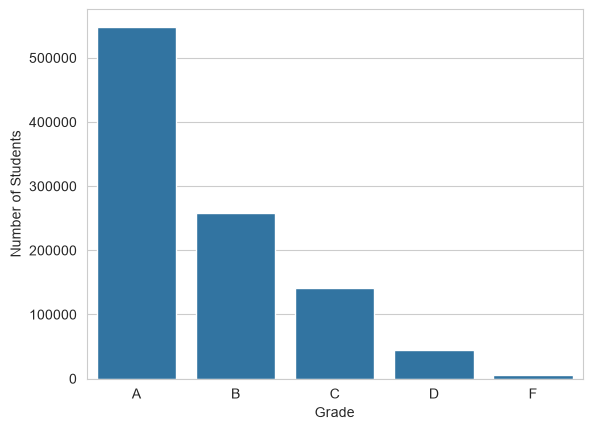

In [133]:
sns.countplot(data=df, x="grade", order=sorted(df["grade"].unique()))
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.show()

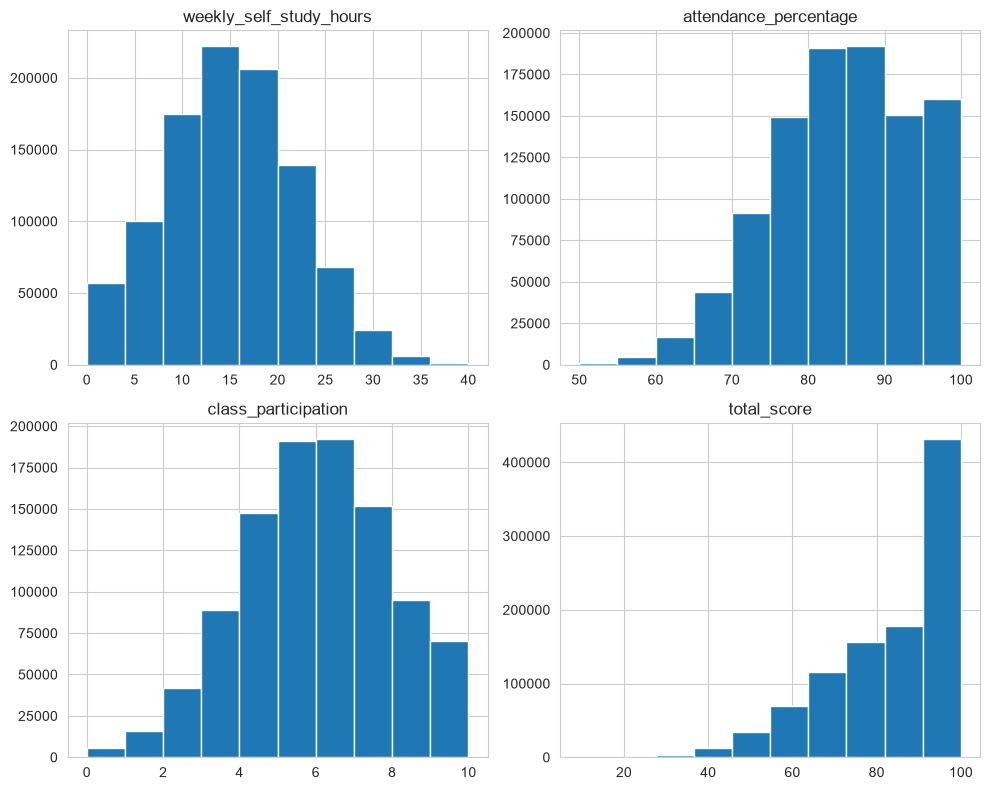

In [134]:
features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]

df[features].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

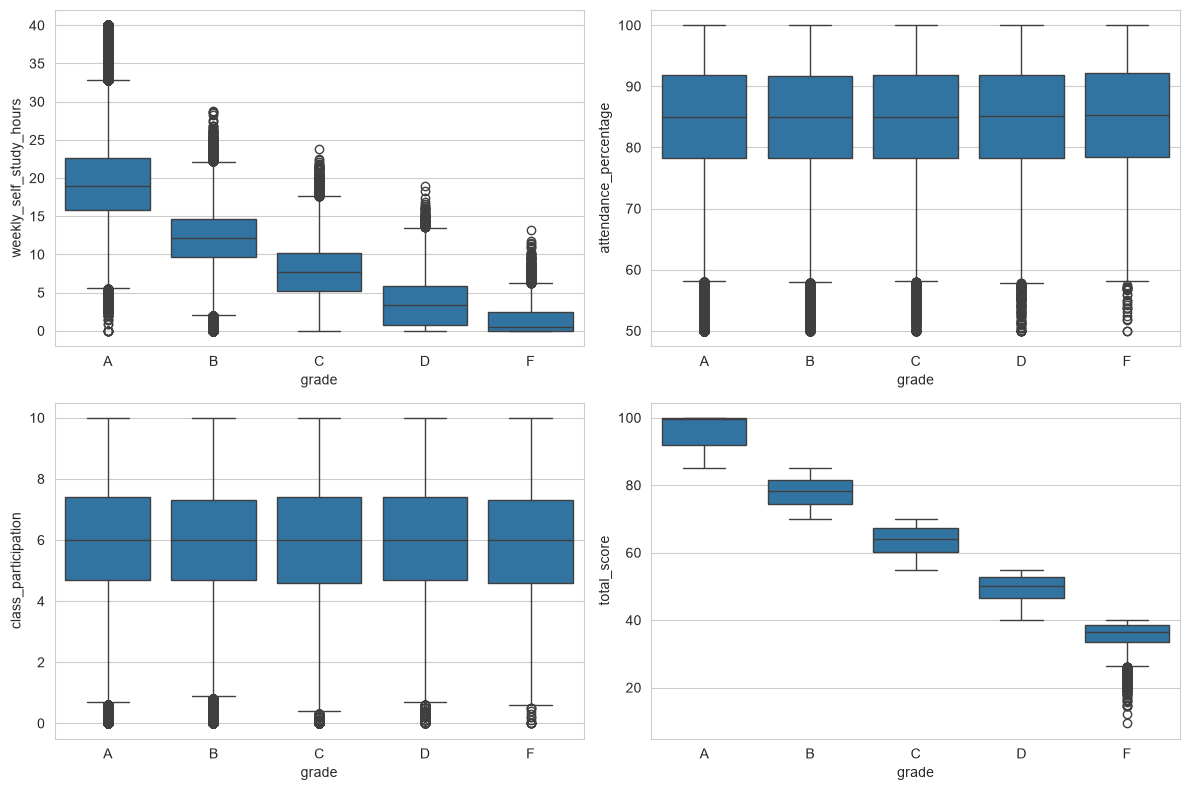

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="grade", y="weekly_self_study_hours", ax=axes[0, 0])
sns.boxplot(data=df, x="grade", y="attendance_percentage", ax=axes[0, 1])
sns.boxplot(data=df, x="grade", y="class_participation", ax=axes[1, 0])
sns.boxplot(data=df, x="grade", y="total_score", ax=axes[1, 1])

plt.tight_layout()
plt.show()

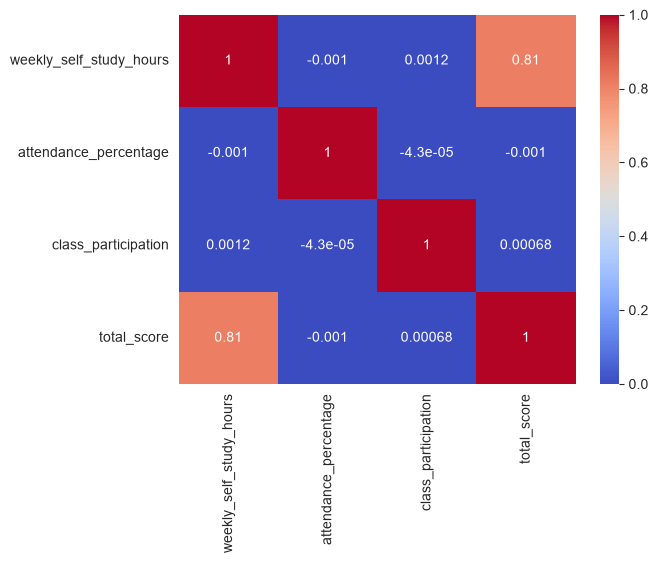

In [136]:
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm")
plt.show()

In [137]:
df.groupby("grade")["total_score"].agg(["min", "max", "mean"])

,min,max,mean
grade,,,
A,85.0,100.0,96.042375
B,70.0,85.0,77.946590
C,55.0,70.0,63.564524
D,40.0,55.0,49.380346
F,9.4,40.0,35.474146


##  Data Preprocessing

In [138]:
df["pass_fail"] = df["grade"].map({
    "A": "Pass",
    "B": "Pass",
    "C": "Pass",
    "D": "Pass",
    "F": "Fail"
})

In [139]:
df["pass_fail"].value_counts()

pass_fail
Pass    993796
Fail      6204
Name: count, dtype: int64

In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
df = df.drop(columns=["student_id", "grade", "total_score"])

In [143]:
df.head()

,weekly_self_study_hours,attendance_percentage,class_participation,pass_fail
0,18.5,95.6,3.8,Pass
1,14.0,80.0,2.5,Pass
2,19.5,86.3,5.3,Pass
3,25.7,70.2,7.0,Pass
4,13.4,81.9,6.9,Pass


In [144]:
df.columns

Index(['weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'pass_fail'],
      dtype='str')

In [145]:
X = df.drop(columns="pass_fail")
y = df["pass_fail"]

In [146]:
X.head()

,weekly_self_study_hours,attendance_percentage,class_participation
0,18.5,95.6,3.8
1,14.0,80.0,2.5
2,19.5,86.3,5.3
3,25.7,70.2,7.0
4,13.4,81.9,6.9


In [147]:
y.head()

0    Pass
1    Pass
2    Pass
3    Pass
4    Pass
Name: pass_fail, dtype: str

In [148]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [149]:
X_train.shape, X_test.shape

((800000, 3), (200000, 3))

In [150]:
y_train.value_counts(normalize=True)

pass_fail
Pass    0.993796
Fail    0.006204
Name: proportion, dtype: float64

In [151]:
y_test.value_counts(normalize=True)

pass_fail
Pass    0.993795
Fail    0.006205
Name: proportion, dtype: float64

In [152]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Model Development

In [153]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [154]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

### Random Forest

In [92]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [155]:
y_pred_rf = random_forest.predict(X_test)

##  Model Evaluation

In [156]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_metrics = [
    accuracy_score(y_test, y_pred_logistic),
    precision_score(y_test, y_pred_logistic, pos_label="Fail"),
    recall_score(y_test, y_pred_logistic, pos_label="Fail"),
    f1_score(y_test, y_pred_logistic, pos_label="Fail")
]

rf_metrics = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf, pos_label="Fail"),
    recall_score(y_test, y_pred_rf, pos_label="Fail"),
    f1_score(y_test, y_pred_rf, pos_label="Fail")
]

In [157]:
results = pd.DataFrame(
    [logistic_metrics, rf_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1 Score"],
    index=["Logistic Regression", "Random Forest"]
)

results

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.910225,0.061450,0.943594,0.115387
Random Forest,0.987855,0.124526,0.158743,0.139568


In [158]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=["Pass", "Fail"])
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["Pass", "Fail"])

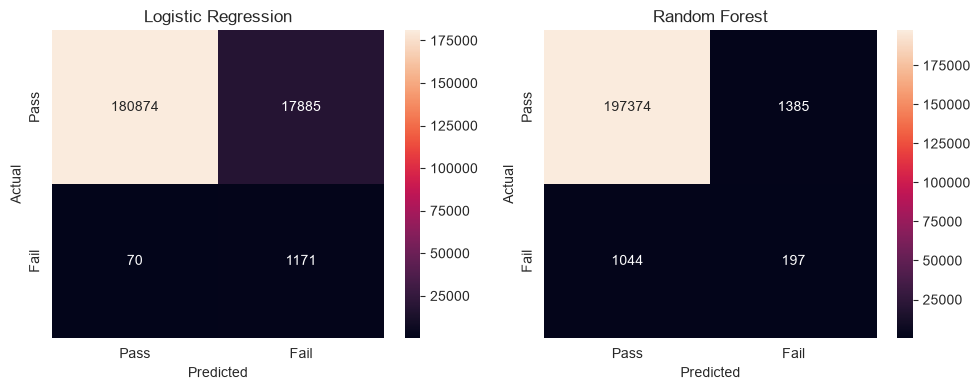

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"],
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"],
    ax=axes[1]
)

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

##  Model Comparison

In [160]:
results

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.910225,0.061450,0.943594,0.115387
Random Forest,0.987855,0.124526,0.158743,0.139568


##  Final Model Selection

In [161]:
results.round(4)

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.9102,0.0615,0.9436,0.1154
Random Forest,0.9879,0.1245,0.1587,0.1396


In [162]:
selected_model = logistic_model
selected_model_name = "Logistic Regression"

selected_model_name

'Logistic Regression'

In [163]:
coefficients = pd.Series(
    logistic_model.coef_[0],
    index=X.columns
)

coefficients.sort_values(ascending=False)

weekly_self_study_hours    4.444028
class_participation        0.019701
attendance_percentage     -0.037693
dtype: float64

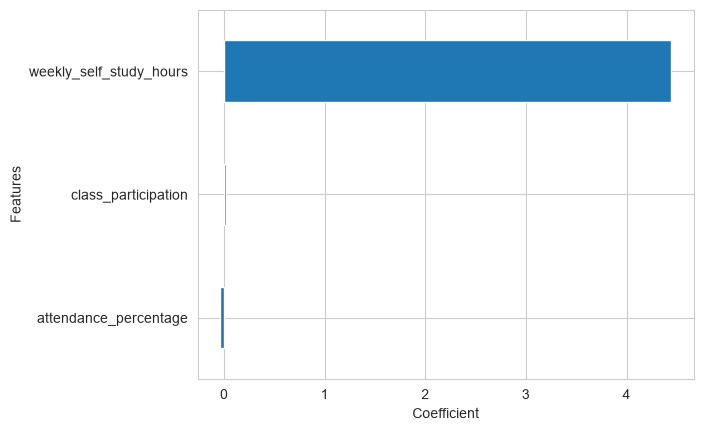

In [164]:
coefficients.sort_values().plot(kind="barh")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.show()

In [165]:
logistic_model.classes_

array(['Fail', 'Pass'], dtype=object)

##  Student Performance Prediction

In [166]:
def predict_student(study_hours, attendance, participation):
    new_student = pd.DataFrame({
        "weekly_self_study_hours": [study_hours],
        "attendance_percentage": [attendance],
        "class_participation": [participation]
    })

    new_student_scaled = scaler.transform(new_student)
    prediction = selected_model.predict(new_student_scaled)

    return prediction[0]

In [167]:
predict_student(20, 90, 8)

'Pass'

In [168]:
fail_student = X_test[y_test == "Fail"].iloc[[0]]

fail_student

,weekly_self_study_hours,attendance_percentage,class_participation
587901,1.5,87.0,2.0


In [169]:
selected_model.predict(
    scaler.transform(fail_student)
)

array(['Fail'], dtype=object)

### Example Predictions

In [170]:
study_hours = 5
attendance = 70
participation = 3

predict_student(study_hours, attendance, participation)

'Fail'

In [171]:
study_hours = 20
attendance = 90
participation = 8

predict_student(study_hours, attendance, participation)

'Pass'

study_hours = 12
attendance = 75
participation = 5

predict_student(study_hours, attendance, participation)

In [172]:
study_hours = 4
attendance = 95
participation = 7

predict_student(study_hours, attendance, participation)

'Fail'

In [174]:
study_hours = float(input("Enter weekly self-study hours: "))
attendance = float(input("Enter attendance percentage: "))
participation = float(input("Enter class participation score: "))

prediction = predict_student(study_hours, attendance, participation)

print("Predicted Result:", prediction)

Enter weekly self-study hours:  30
Enter attendance percentage:  55
Enter class participation score:  10


Predicted Result: Pass


In [173]:
study_hours = float(input("Enter weekly self-study hours: "))
attendance = float(input("Enter attendance percentage: "))
participation = float(input("Enter class participation score: "))

prediction = predict_student(study_hours, attendance, participation)

print("Predicted Result:", prediction)

Enter weekly self-study hours:  10
Enter attendance percentage:  5
Enter class participation score:  2


Predicted Result: Pass
